# Cost-Aware Simulation Based Inference

**References:**
- Bharti et al. (2025) — [Cost-aware simulation-based inference](https://arxiv.org/abs/2410.07930)

Generating samples for simulation-based inference can have a high computational cost. The cost of each individual simulation often depends on on the parameter value used for simulation. Cost-aware SBI uses importance sampling to encourage sampling from the computationally cheaper parameterisations of the model. In this way it can significantly reduce simulation costs, without any changes to the simulator itself. 

## 1. Imports

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import pickle
import time
import numpy as np

import matplotlib.pyplot as plt
import bayesflow as bf

from cost_interp_model import CostInterpModel
from cost_train_plots import * 


INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).
/u/08/sohkanj1/unix/Documents/projects/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Input Cost Data as a function of the simulator parameters

In a real scenario, cost can be any value that is meaningful for the simulator, for example wall-clock time of the simulation, that may depend on the parameters used. A function can be constructed by interpolating existing simulated data, for example, by fitting a Gaussian process fitted to the data. These samples can then be reused later.  

In this toy example, we use an analytic function of the parameters for the SIR model ($\beta ,\gamma$) to mimic the cost behaviour of the model. 

In [2]:
def cost_model(theta: np.ndarray) -> np.ndarray:
    """
    An analytic cost model that predicts the cost as a function of input parameters theta.
    
    Parameters
    ----------
    theta : np.ndarray
        The parameter values to predict the cost for. 
        Shape (m,) or (m, d).

    Returns
    -------
    cost : np.ndarray
        The cost, with shape (m,).
    """
                                                                                                                            
    theta = np.asarray(theta, dtype=float)                                                                                                   
                                                                                                                                            
    if theta.ndim == 1:                                                                                                                      
        # Cost is high (near 1.0) when theta is small, decays to 0 as theta grows                                                            
        cost = np.exp(-np.abs(theta))                                                                                                        
    else:                                                                                                                                    
        # Sum of decays across dimensions                                                                                                    
        cost = np.sum(np.exp(-np.abs(theta)), axis=1)                                                                                        
                                                                                                                                            
    return cost             


We can visualise how the cost changes with the parameters $\beta$ and $\gamma$. 

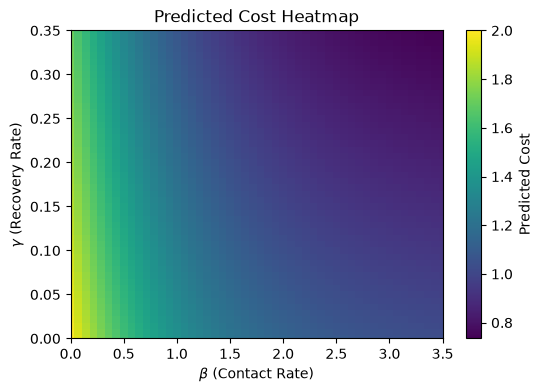

In [7]:

def plot_cost_landscape(cost_model):
    #add predicted cost plot

    # Create a grid for cost visualization
    b_min, b_max = 0, 3.5 # Approximate ranges for SIR beta
    g_min, g_max = 0, 0.35   # Approximate ranges for SIR gamma
    B, G = np.meshgrid(np.linspace(b_min, b_max, 50), np.linspace(g_min, g_max, 50))
    grid_theta = np.stack([B.ravel(), G.ravel()], axis=1)

    predicted_costs = cost_model(grid_theta)
    COST = predicted_costs.reshape(B.shape)

    fig = plt.figure(figsize=(6, 4))
    plt.xlim((b_min, b_max))
    plt.ylim((g_min, g_max))
    plt.pcolormesh(B, G, COST, cmap="viridis", shading="auto")
    plt.colorbar(label="Predicted Cost")
    plt.xlabel(r"$\beta$ (Contact Rate)")
    plt.ylabel(r"$\gamma$ (Recovery Rate)")
    plt.title("Predicted Cost Heatmap")
    #plt.show()
    return fig 

fig = plot_cost_landscape(cost_model)
plt.show(fig)

## 4. Initialize Cost-Aware Simulator

The `CostAwareSimulator` wraps the base simulator and uses the cost model to filter samples based on a regularised cost function $g(c(\theta))$. Since we don't want to use the expensive simulator until we have selected cost-effective prior samples, the simulator accepts the prior as input.

In [8]:

#use any prior
#here we use a benchmark prior example
prior=bf.simulators.benchmark_simulators.SIR().prior 

#initialise the simulator 
cost_aware_sim = bf.simulators.CostAwareSimulator(prior=prior, cost_model=cost_model)


## 5. Cost-Aware Sampling

We use rejection sampling to obtain a set of cost-efficient parameters. For constructing the sampler, we use a regularisation of the cost                                
                                                                                                                                                
   \begin{equation}                                                                                                                             
       g(c) = \max\left(g_{\min}, (c + g_{\min})^k\right)                                                                                       
   \end{equation}      
                                                                            
with $g_{\min}$ is a minimum value (offset) to prevent the weight from becoming zero or too small and $k$ is a power factor for cost regularization. Both parameters are configurable through the class properties of the CostAwareSampler.
                                                   
Candidates $\theta$ drawn from the prior distribution are accepted based on a regularization of the cost $g(c)$. The acceptance probability is 
\begin{equation}                                                                                                                             
       P(\text{accept} \mid \theta) = \frac{g_{\min}}{g(c(\theta))}                                                                             
   \end{equation}   

In [9]:
print("\nTesting cost-aware sampling...")
num_samples = 1000

#Use the cost-aware sampling method
accepted_samples = cost_aware_sim.sample(batch_shape=(num_samples,1))
accepted_theta = accepted_samples.get("parameters")

#may return more than the requested number of samples. This is because of the way that rejection_sample works, in batches until it reaches the total
#number of samples
print(f"Successfully sampled {len(accepted_theta)} cost-efficient parameters.")



Testing cost-aware sampling...
Cost Aware simulator does rejection sampling of the prior for 1 different k values
Successfully sampled 1000 cost-efficient parameters.


The samples generated by cost-aware sampling can be compared with those taken directly from the prior. 

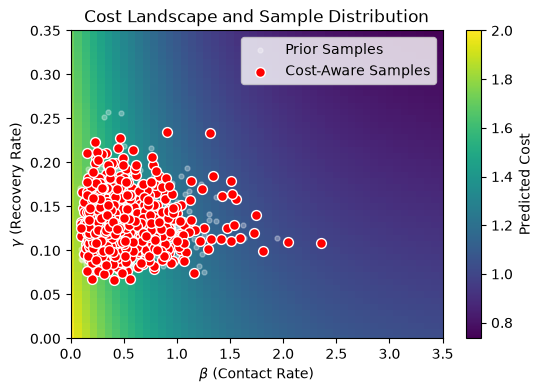

In [10]:

# Prior samples for comparison
prior_samples = np.array([prior() for _ in range(len(accepted_theta))])

def plot_prior_samples(cost_model,prior_samples,accepted_theta):
   
    fig = plot_cost_landscape(cost_model) #plt.figure(figsize=(6, 4))
    
    plt.scatter(
        prior_samples[:, 0],
        prior_samples[:, 1],
        color="white",
        alpha=0.3,
        s=50,
        label="Prior Samples",
        marker=".",
    )

    # Accepted samples
    if len(accepted_theta) > 0:
        plt.scatter(
            accepted_theta[:, 0],
            accepted_theta[:, 1],
            color="red",
            edgecolors="white",
            s=50,
            label="Cost-Aware Samples",
            marker="o",
        )

    plt.xlabel(r"$\beta$ (Contact Rate)")
    plt.ylabel(r"$\gamma$ (Recovery Rate)")
    plt.title("Cost Landscape and Sample Distribution")
    plt.legend()
    return fig

fig = plot_prior_samples(cost_model,prior_samples,accepted_theta)
plt.show(fig)

We can see how the distribution of the parameters has been affected by moving to more cost-effective options.

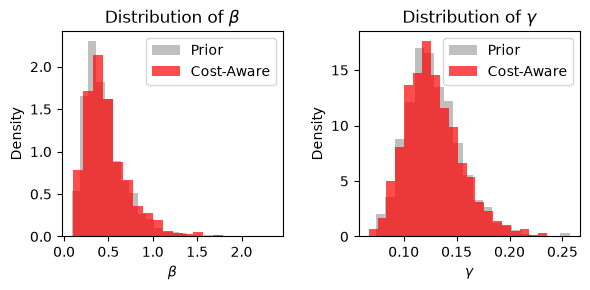

In [11]:

def plot_histograms(prior_samples,accepted_theta):

    # Visualise the change in parameter distributions
    plt.figure(figsize=(6, 3))

    # Distribution of beta
    plt.subplot(1, 2, 1)
    plt.hist(prior_samples[:, 0], bins=20, alpha=0.5, label="Prior", color="gray",density=True)
    if len(accepted_theta) > 0:
        plt.hist(accepted_theta[:, 0], bins=20, alpha=0.7, label="Cost-Aware", color="red",density=True)
    plt.xlabel(r"$\beta$")
    plt.ylabel("Density")
    plt.title(r"Distribution of $\beta$")
    plt.legend()

    # Distribution of gamma
    plt.subplot(1, 2, 2)
    plt.hist(prior_samples[:, 1], bins=20, alpha=0.5, label="Prior", color="gray",density=True)
    if len(accepted_theta) > 0:
        plt.hist(accepted_theta[:, 1], bins=20, alpha=0.7, label="Cost-Aware", color="red",density=True)
    plt.xlabel(r"$\gamma$")
    plt.ylabel("Density")
    plt.title(r"Distribution of $\gamma$")
    plt.legend()

    plt.tight_layout()

    return fig 

fig = plot_histograms(prior_samples, accepted_theta)

plt.show(fig)

## 7. Performance Metrics

We evaluate the effectiveness of the cost-aware sampling using Effective Sample Size (ESS) and Computational Gain (CG) for the accepted samples.

                                                                   
   \begin{equation}                                                                                                                             
       \text{ESS} = \frac{\left( \sum_{i=1}^{N} g(c(\theta_i)) \right)^2}{N \sum_{i=1}^{N} g(c(\theta_i))^2}                                                          
   \end{equation}         


In [12]:
metrics = cost_aware_sim.compute_metrics({"theta": accepted_theta})
print(f"  Effective Sample Size: {metrics['ess']:.2f}")

  Effective Sample Size: 0.99


Computational gain is a measure of the reduction of the cost, given by the cost function, by using the cost-aware samples over plainly sampling the prior. The metric is calculated as the ratio of the average cost of samples drawn from the original prior to the average cost of the samples accepted by the cost-aware sampler.


\begin{equation*}                 
\text{CG} = \frac{\mathbb{E}_{\theta \sim \pi(\theta)} (c(\theta))}{\mathbb{E}_{\theta \sim \pi_{\text{aware}}(\theta)} (c(\theta))}    
\end{equation*}                                        
       
This is estimated as                 
\begin{equation*}                                              \text{CG} \approx \frac{\frac{1}{N} \sum_{j=1}^{N} c(\theta_j^{\text{prior}})}{\frac{1}{N} \sum_{i=1}^{N} c(\theta_i^{\text{accepted}})}
\end{equation*}     
where samples $\theta_j^{\text{prior}}$ are taken from the original prior distribution. 


In [13]:
print(f"  Computational Gain:  {metrics['cg']:.2f}")

  Computational Gain:  1.01


## 9. Generating Expensive Samples

Now that we have out cost-efficient values of the prior, we can finally sample the expensive simulator. Once we have the samples, we compute their relative weights 

In [14]:
#define the simulator
sir_sim = bf.simulators.benchmark_simulators.SIR()

num_accepted = len(accepted_theta)

accepted_theta = accepted_samples["parameters"]

train_observations = np.array([sir_sim.observation_model(t) for t in accepted_theta])
print(f"\nSuccessfully simulated {len(train_observations)} samples using the expensive simulator.")



Successfully simulated 1000 samples using the expensive simulator.


## 10. Computing Importance Weights

We use self-normalised weights $w_i$ for the i-th accepted sample $\theta_i$. Let $N$ be the total number of accepted samples in the batch. 
\begin{equation}                                                                                                                             
       w_i = \frac{g(c(\theta_i))}{\sum_{j=1}^{N} g(c(\theta_j))}                                                                               
   \end{equation}                                                                

In [15]:
train_weights = cost_aware_sim.compute_weights(accepted_samples)
train_weights = np.asarray(train_weights, dtype=np.float32).reshape(-1, 1)


## 10. Inference

We can now plug the training data into the existing Bayesflow framework. The training weights are passed to the workflow via adapter

In [16]:

train_data = {
    "theta": np.asarray(accepted_theta),
    "observations": np.asarray(train_observations),
    "weights": train_weights}

adapter = (
    bf.Adapter()
    .to_array()
    .convert_dtype("float64", "float32")
    .concatenate(["theta"], into="inference_variables")
    .concatenate(["observations"], into="inference_conditions")
    .rename("weights", "sample_weight")
)


inference_net = bf.networks.PointNetwork(points="mean")

workflow = bf.BasicWorkflow(
    simulator=cost_aware_sim,
    adapter=adapter,
    inference_network=inference_net,
)

In [17]:
history = workflow.fit_offline(                                                                                                                               
       data=train_data,                                                                                                                                
       epochs=20,                                                                                                                                     
       batch_size=32                                                                                                                                   
   )

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - PointNetwork/mean: 8.2843e-07 - loss: 8.2843e-07
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - PointNetwork/mean: 8.4178e-07 - loss: 8.4178e-07
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - PointNetwork/mean: 7.7697e-07 - loss: 7.7697e-07
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - PointNetwork/mean: 7.1946e-07 - loss: 7.1946e-07
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - PointNetwork/mean: 6.7495e-07 - loss: 6.7495e-07
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - PointNetwork/mean: 6.4089e-07 - loss: 6.4089e-07
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - PointNetwork/mean: 6.2050e-07 - loss: 6.2050e-07
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - PointNetwork/mean: 5.9866e-07 - loss: 5.9866e-07
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - PointNetwork/mean: 5.8469e-07 - loss: 5.8469e-07
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - PointNetwork/mean: 5.7750e-07

INFO:bayesflow:Training completed in 11.49 seconds.


In [ ]:
                                                                                                                                       
test_res = workflow.approximator.estimate({"o": obs})                                                                                        
print(test_res.keys()) # See the parameter names                                                                                             
print(test_res["theta"].keys()) # See the available statistics (e.g., 'mean')   

In [23]:
from cost_train_plots import *
num_samples = 100                                                                                                                            
dim = 2 # e.g., beta and gamma                                                                                                               
        
# A. Generate Random Ground Truths from a Prior                                                                                              
# We pick truths from a Uniform distribution                                                                                                 
truths = np.random.uniform(0.1, 1.0, size=(num_samples, dim))                                                                                
                                                                                                                                            
# B. Generate Observations and Estimates                                                                                                     
# We simulate the process: Truth -> Observation -> Estimate                                                                                  
observations = []                                                                                                                            
estimates = []                                                                                                                               
prior_samples = [] # The samples the simulator 'considered'                                                                                  
                                                                                                                                            
for i in range(num_samples):                                                                                                                 
    theta_true = truths[i]              

all_obs = []                                                                                                                            
# ==========================
for theta_true in truths:                                                                                                                    
    obs = sir_sim.observation_model(theta_true)                                                                                              
                                                                                                                                            
    # Add batch dimension: (obs_dim,) -> (1, obs_dim)                                                                                        
    obs_batched = obs[np.newaxis, :]                                                                                                         
                                                                                                                                        
# Use the workflow's approximator                                                                                                        
result = workflow.approximator.estimate({"o": obs_batched})                                                                              
                                                                                                                                        
# Extract and flatten (since it's a batch of 1)                                                                                          
estimate = result["theta"]["mean"][0]                                                                                                    
estimates.append(estimate)                                                                                                   


ValueError: Exception encountered when calling DenseBlock.call().

[1mInput 0 with name 'None' of layer 'dense' is incompatible with the layer: expected axis -1 of input shape to have value 10, but received input with shape (1, 1)[0m

Arguments received by DenseBlock.call():
  • x=torch.Tensor(shape=torch.Size([1, 1]), dtype=float32)
  • training=False

In [ ]:
# 3. PLOTTING                                                                                                                                
# ==========================================                                                                                                 
                                                                                                                                            
# Plot for the first parameter (e.g., beta)                                                                                                  
plot_accuracy_vs_cost(                                                                                                                       
    truths=truths,                                                                                                                           
    estimates=estimates,                                                                                                                     
    prior_samples=prior_samples,                                                                                                             
    cost_model=cost_model,                                                                                                       
    parameter_index=0,                                                                                                                       
    parameter_name="beta"                                                                                                                    
)                                                                                                                                            
                                                                                                                                            
plot_recovery_by_cost(                                                                                                                       
    truths=truths,                                                                                                                           
    estimates=estimates,                                                                                                                     
    prior_samples=prior_samples,                                                                                                             
    cost_model=cost_model,                                                                                                       
    parameter_index=0,                                                                                                                       
    parameter_name="beta"                                                                                                                    
)                                                                                                                                            
                                                                                                                                            
# Calculate costs separately to plot the distribution                                                                                        
costs = cost_model(prior_samples)                                                                                                
plot_cost_distribution(costs)        

## 10. Multiple Importance sampling 
When the true posterior lies in the computationally costly region, choosing a single penalty function based on CG and ESS alone may lead to sub-optimal results. This is why we may want to consider multiple cost-aware priors, with different values for the regularisation power $k$.  

                                                                      
The CostAwareSimulator supports multiple importance sampling by accepting an array of k values. The simulator executes the rejection sampling process for each value of k provided; the total number of samples requested via batch_samples is split equally among these values. The resulting weights are then self-normalized relative to each k-group.  
 

In [ ]:
regularisation_powers = [0,1,2,3]
num_thetas = 1000 #total number of samples needed

mis_cost_simulator = bf.simulators.CostAwareSimulator(prior=prior, cost_model=cost_model)

In [ ]:
accepted_samples_mis = mis_cost_simulator.sample(batch_shape=(num_samples,1),k=[0,2,3,5])

fig = plot_prior_samples(cost_model,prior_samples,accepted_theta)
plt.show(fig)

In [ ]:
fig = plot_histograms(prior_samples,accepted_theta=accepted_samples_mis["parameters"])
fig.suptitle("Comparison of Samples from the Prior with Mutliple Importance Sampling")
plt.show(fig)

In [ ]:

accepted_theta_mis = accepted_samples_mis["parameters"]
train_observations_mis = np.array([sir_sim.observation_model(t) for t in accepted_theta_mis])
print(f"\nSuccessfully simulated {len(train_observations_mis)} samples using the expensive simulator.")

#compute the weights using accepted samples
train_weights_mis = cost_aware_sim.compute_weights(accepted_samples_mis)
train_weights_mis = np.asarray(train_weights_mis, dtype=np.float32).reshape(-1, 1)

#setup the training data
train_data_mis = {
    "theta": np.asarray(accepted_theta_mis),
    "observations": np.asarray(train_observations_mis),
    "weights": train_weights_mis}

adapter_mis = (
    bf.Adapter()
    .to_array()
    .convert_dtype("float64", "float32")
    .concatenate(["theta"], into="inference_variables")
    .concatenate(["observations"], into="inference_conditions")
    .rename("weights", "sample_weight")
)

inference_net_mis = bf.networks.PointNetwork(points="mean")

workflow_mis = bf.BasicWorkflow(
    simulator=mis_cost_simulator,
    adapter=adapter_mis,
    inference_network=inference_net_mis,
)

history_mis = workflow_mis.fit_offline(                                                                                                                               
       data=train_data_mis,                                                                                                                                
       epochs=20,                                                                                                                                     
       batch_size=32                                                                                                                                   
   )

In [ ]:
plot_accuracy_vs_cost(truths, accepted_theta[:, 0], history)                                                                                 
plot_cost_distribution(history)                                                                                                              
plot_recovery_by_cost(truths, accepted_theta[:, 0], history) 